# Active Brownian Particles: Introductory Models on Self-Propulsion

Brownian Particles without propulsion move due to stochastic collisions arising from the thermal motion of the molecules. To add propulsion to our system, we assume an additional inflow of energy leading to active motion, which can be described effectively by negative dissipation in the direction of motion, i.e., a non-linear friction term that can take negative values. Generally, the Langevin equation for the Active Brownian Particles (ABPs) looks like:
$$ \frac{d\mathbf{r}}{dt} = \mathbf{v} \tag{1}$$
$$ \frac{d\mathbf{v}}{dt} = -\gamma(r,v)\mathbf{v} - \nabla U(r) + \text{noise}\tag{2}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helmholtz_rayleigh import simulate_helmholtz_rayleigh_2d_cartesian
from schienbein_gruler import simulate_schienbein_gruler_2d_cartesian
from depot_model import simulate_depot_model_2d_cartesian

In [2]:
#Spatially dependent Potential 
def U(x, y):
    return np.sin(x/5) * np.cos(y/6)

## The Rayleigh-Helmholtz Model

The friction term is given as: $$\gamma(\mathbf{v}) = -\alpha + \beta v^2 = \beta\left(v^2 - v_0^2\right)  \tag{3}$$ Where $v_0$ is the characteristic stationary (self-propelled) speed of the particle. It is the speed at which the effective friction becomes zero. We can use this Rayleigh-Helmholtz friction and integrate the trajectory of the particle. The discretised velocity and position in the Euler-Maruyama scheme are given as:


$$ \mathbf{v}_{n+1} = \mathbf{v}_n - \frac{\beta}{m} \left(|\mathbf{v}_n|^2 - v_0^2\right) \mathbf{v}_n \,\Delta t + \frac{\sqrt{2D}}{m}\sqrt{\Delta t}\,\boldsymbol{\xi}_n \tag{4}
$$

$$ \mathbf{r}_{n+1} = \mathbf{r}_n + \mathbf{v}_n \,\Delta t \tag{5} $$

Below is the function `simulate_helmholtz_rayleigh_2d_cartesian`, which integrates the particle's trajectory.

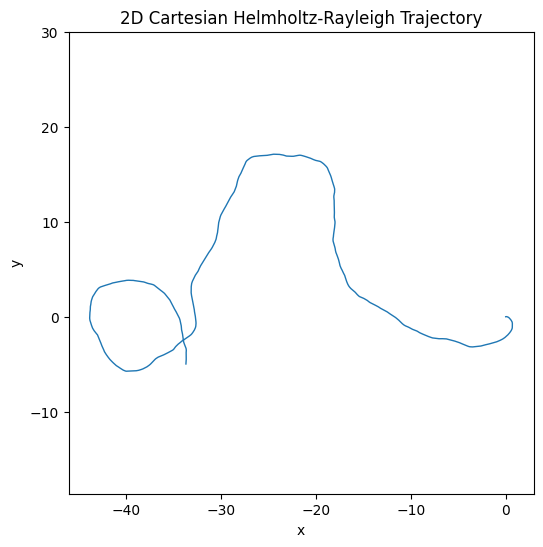

In [3]:
time, r, v, speed = simulate_helmholtz_rayleigh_2d_cartesian(
    U=U,
    n_steps=100_000,
    dt=1e-3,
    beta=1.0,
    v0=1.0,
    D=0.03,
    r0=np.array([0.0, 0.0]),
    v_init=np.array([0.2, 0.1]),
    grad_h=1e-5,
    seed=90,
)

plt.figure(figsize=(6, 6))
plt.plot(r[:, 0], r[:, 1], lw=1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Cartesian Helmholtz-Rayleigh Trajectory")
plt.axis("equal")
plt.show()

## The Schienbein-Grüler Friction

In this model, the propulsion term depends approximately linearly on the velocity magnitude rather than cubically. The restoring tendency toward $v_0$ is therefore weaker and more direct. At low speeds, the model provides nearly constant propulsion toward the preferred speed, making it especially useful for migrating cells or crawling organisms. The friction term is given as:
$$
\gamma(\mathbf{v})=
\gamma_0
\left(
1 - \frac{v_0}{|\mathbf{v}|}
\right) = \gamma_0 \left( s - v_0\right)\hat{e_v} \tag{6}
$$
Where $s= |v|$ is the speed of the particle. $\hat{e_v} = v/s$ is the direction of the velocity vector. The particle's trajectory can be obtained by integrating the Langevin equation. Here, we use the Schienbein-Grüler friction in the Langevin equation and discretise it using the Euler-Maruyama scheme as follows:

$$
\mathbf{v}_{n+1} =
\mathbf{v}_n -
\frac{\gamma_0}{m}
\left(
1 - \frac{v_0}{|\mathbf{v}_n|}
\right)
\mathbf{v}_n \,\Delta t
+
\frac{\sqrt{2D}}{m}\sqrt{\Delta t}\,\boldsymbol{\xi}_n \tag{7}
$$

$$
\mathbf{r}_{n+1}=
\mathbf{r}_n
+
\mathbf{v}_n \,\Delta t \tag{8}
$$

The function `simulate_schienbein_gruler_2d_cartesian` uses the above scheme to integrate and give the particle's trajectory.

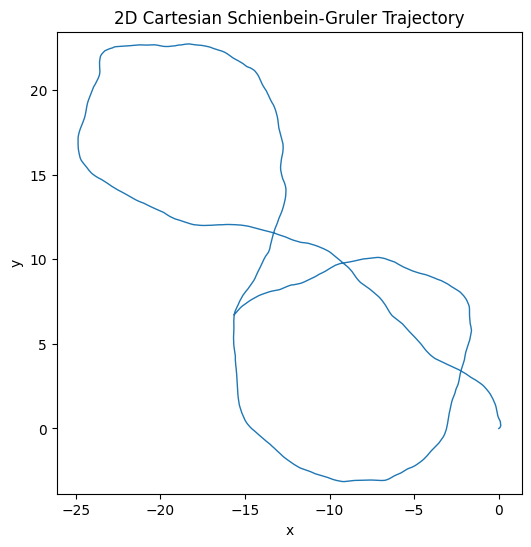

In [4]:
time, r, v, speed = simulate_schienbein_gruler_2d_cartesian(
    U=U,
    n_steps=100_000,
    dt=1e-3,
    alpha=1.0,
    v0=1.0,
    D=0.03,
    r0=np.array([0.0, 0.0]),
    v_init=np.array([0.2, 0.1]),
    grad_h=1e-5,
    seed=8,
)
plt.figure(figsize=(6, 6))
plt.plot(r[:, 0], r[:, 1], lw=1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Cartesian Schienbein-Gruler Trajectory")
plt.axis("equal")
plt.show()

## The Depot Model

Here, we assume that the particle absorbs energy from an external source and stores some of this additional energy in an internal depot or storage $e(t)$. The amount of energy in the depot can be controlled by:
1. Take-up energy from the environment ($q(r)$), which is the space-dependent pump rate of energy.
2. Internal Dissipation, which is basically energy that is lost to the environment without any contribution to the motion ($c$)
3. Conversion of internal energy into motion ($h(v)$)

Simple ansatz is $q(r) \equiv q_0$ and $h(v) \equiv dv^2$  

The Langevin equation then looks like:
$$ \frac{d}{dt}\mathbf{v} + \gamma_0\mathbf{v} + \nabla U(r) = de(t) + \text{noise} \tag{9} $$

The internal energy dynamics are given by:
$$ \frac{de}{dt} = q_0 - c e - d e v^2$$
This equation is completely deterministic and has no stochastic terms. Euler-Maruyama discretisation of the Langevin equation:
$$
\mathbf{v}_{n+1} = \mathbf{v}_n + \frac{1}{m} \left[ -\gamma \mathbf{v}_n + d e_n \mathbf{v}_n - \nabla U(\mathbf{r}_n) \right]\Delta t
+
\frac{\sqrt{2D}}{m}\sqrt{\Delta t}\,\boldsymbol{\xi}_n \tag{10}
$$

$$
\mathbf{r}_{n+1} = \mathbf{r}_n + \mathbf{v}_n \Delta t \tag{11}
$$

Along with the velocity and positions, we update the internal depot:

$$ e_{n+1} = e_n + \left(q_0 - c e_n -
d e_n |\mathbf{v}_n|^2
\right)\Delta t
$$

The function `simulate_depot_model_2d_cartesian` integrates the above equations to give particle trajectories.

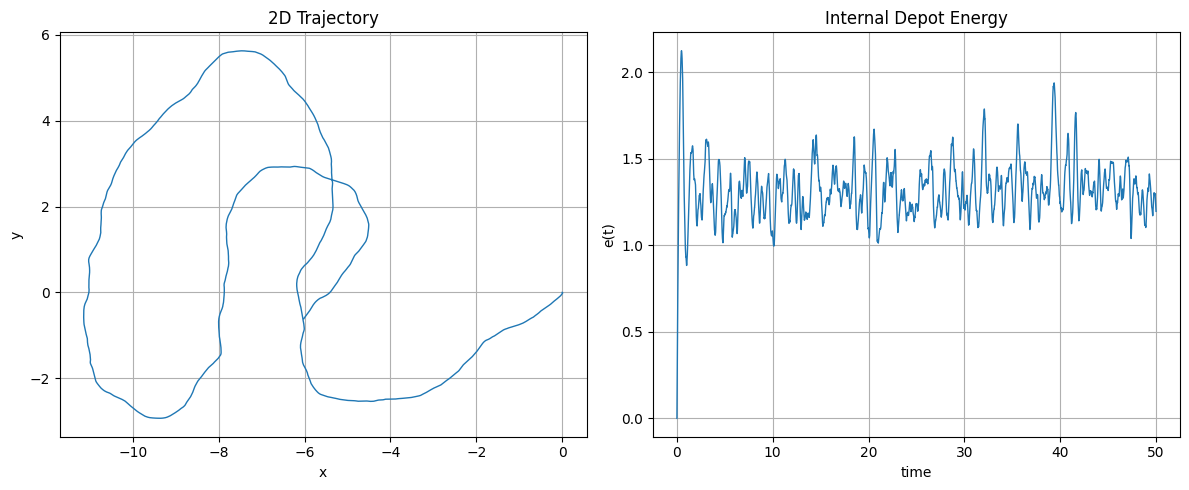

In [5]:
time, r, v, e, speed = simulate_depot_model_2d_cartesian(
    U,
    n_steps=50_000,
    dt=1e-3,
    gamma = 8,
    D=0.05,
    e0 = 0,
    c = 3,
    d = 6,
    q_0 = 9,
    r0=np.array([0.0, 0.0]),
    v_init=np.array([0.1, 0.0]),
    grad_h=1e-5,
    seed=42,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Trajectory plot
axes[0].plot(r[:, 0], r[:, 1], lw=1)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("2D Trajectory")
axes[0].axis("equal")
axes[0].grid(True)
# Internal energy plot
axes[1].plot(time, e, lw=1)
axes[1].set_xlabel("time")
axes[1].set_ylabel("e(t)")
axes[1].set_title("Internal Depot Energy")
axes[1].grid(True)
plt.tight_layout()
plt.show()